# Esperimento Reward Embedding con e senza per l'Agent

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import ast

In [2]:
RESULT_TOT="../data/training_dataset/results/results_combined_new_model_name_wo_edge.csv"
colors = cm.tab10.colors
df = pd.read_csv(RESULT_TOT)
df['model'].unique()

<ArrowStringArray>
[                   'qwen-chat-agent-4-v2',
                          'chat-qwen-base',
                       'qwen-chat-agent-6',
                        'qwen-extractor-3',
                        'qwen-extractor-4',
                        'qwen-extractor-2',
    'qwen-chat-extractor-tuned-lora-16-v1',
                    'qwen-chat-agent-5-v1',
                       'qwen-chat-agent-7',
          'qwen-chat-agent-8-wo-embedding',
                      'qwen-chat-agent-12',
                       'qwen-chat-agent-9',
                'qwen-extractor-5-lora-32',
              'qwen-extractor-6-embedding',
 'qwen_chat_agent_13_dense_reward_30_step',
 'qwen_chat_agent_13_dense_reward_51_step',
                     'qwen_chat_agent_sft',
                      'qwen_extractor_sft',
                       'qwen_combined_sft',
                      'qwen_combined_grpo']
Length: 20, dtype: str

In [3]:
target ='base|qwen-chat-agent-8-wo-embedding|qwen-chat-agent-5-v1|qwen_chat_agent_sft'
models = list(df[df['model'].str.contains(target)]['model'].unique())
labels = ['qwen3:4b','Agent w. embedding reward','Agent w.o. embedding reward', 'Agent SFT']
models

['chat-qwen-base',
 'qwen-chat-agent-5-v1',
 'qwen-chat-agent-8-wo-embedding',
 'qwen_chat_agent_sft']

0.46 	+-0.0203571170187945
0.78 	+-0.01856006949138991
0.49 	+-0.020707762896987305
0.497 	+-0.020958863478143432


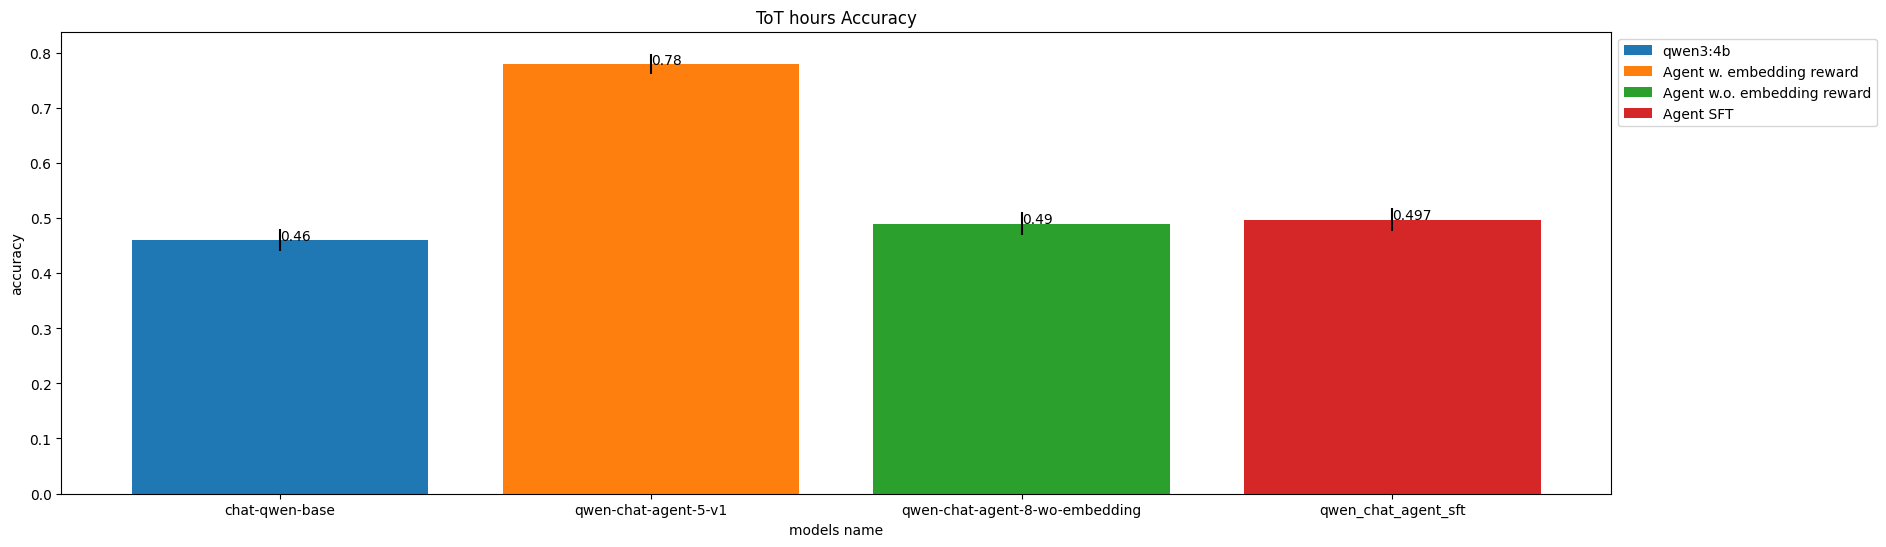

In [4]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
CI_group = []


for model in models:
    g = df.loc[df['model'] == model]
    acc_media = round(                                                                                                                                    
          (g['tot_acc'] * g['n_relevant_fields']).sum() / g['n_relevant_fields'].sum(),                                                                     
          3                                                                                                                                                 
      )                                                                                                                                                                                                                                                                                                      
    # effective n = total field evaluations (not number of rows)                                                                                          
    n = g['n_relevant_fields'].sum()
    # intervallo di confidenza al 90 %
    CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

for media,CI in zip(media_group, CI_group):
        print(f"{media} \t+-{CI}")
        
plt.figure(figsize=(20,6))
plt.bar(models, media_group, yerr=CI_group, color=colors , label=labels)
add_labels(models,media_group)
plt.title("ToT hours Accuracy")
plt.xlabel("models name")
plt.ylabel("accuracy")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))